# 🔍💳 EDA análisis exploratorio de datos para detectar fraudes en transacciones de tarjetas de crédito

Este notebook realiza un análisis exploratorio completo del dataset de transacciones de tarjetas de crédito, identificando patrones y variables clave para la detección de fraude.  
Incluye: carga y verificación de datos, análisis de balance de clases, visualización de variables relevantes, selección de features más distintivas y exportación de muestras balanceadas para modelado.  
Las variables con mayor poder discriminativo son: **Time**, **Amount**, **V3** y **V14**.

> **Objetivo:** Entender el comportamiento de las transacciones y destacar las señales más útiles para modelos de detección de fraude.

In [1]:
#librerias  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)

import os



pandas: 2.2.3
numpy: 2.1.3
seaborn: 0.13.2


📂 **Cargar datos y checks básicos**

En esta sección se realiza la carga del dataset y las primeras verificaciones: dimensiones, tipos de datos, valores nulos y una vista rápida de las primeras filas. Esto permite asegurar que los datos están correctamente importados y listos para el análisis exploratorio.

In [18]:
#ruta
PATH = '../data/raw/creditcard.csv'
try:
    df = pd.read_csv(PATH)
except FileNotFoundError:
    print(f"Archivo no encontrado en {PATH}")

print('Shape:', df.shape)
display(df.head())
print('\nInfo:')
print(df.info())
print('\nNulos por columna:')
print(df.isnull().sum())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21

📊 **Distribución de clases: cantidad y porcentaje**

En esta sección se analiza el balance de clases en el dataset, mostrando tanto el número absoluto de transacciones como el porcentaje que representa cada clase (fraude y no fraude). Esto permite visualizar el fuerte desbalance y la proporción de fraudes detectados. ⚠️

Conteos:
 Class
0    284315
1       492
Name: count, dtype: int64
Porcentajes (%):
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


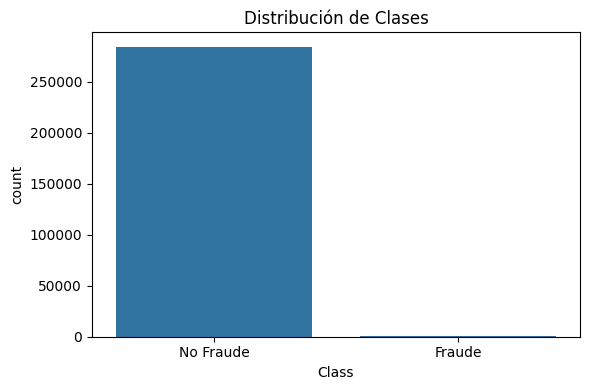

In [19]:
count = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True) * 100
print('Conteos:\n', count)
print('Porcentajes (%):\n', pct)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.xticks([0,1], ['No Fraude', 'Fraude'])
plt.title('Distribución de Clases')
plt.tight_layout()
plt.show()

📈 **Estadísticas y visualización de Amount y Time**  
En esta sección se exploran las variables clave del dataset: **Amount** y **Time**. Se analizan sus estadísticas descriptivas, la presencia de outliers y se aplican transformaciones (como logaritmos) para mejorar la visualización y el análisis. Estas acciones permiten entender mejor la distribución de los montos y el comportamiento temporal de las transacciones. 🔍💸⏰

Amount descr: count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
Time descr: count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


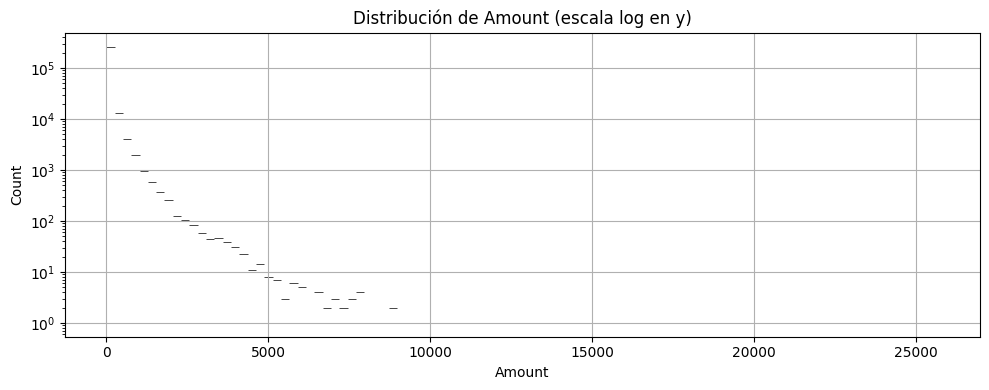

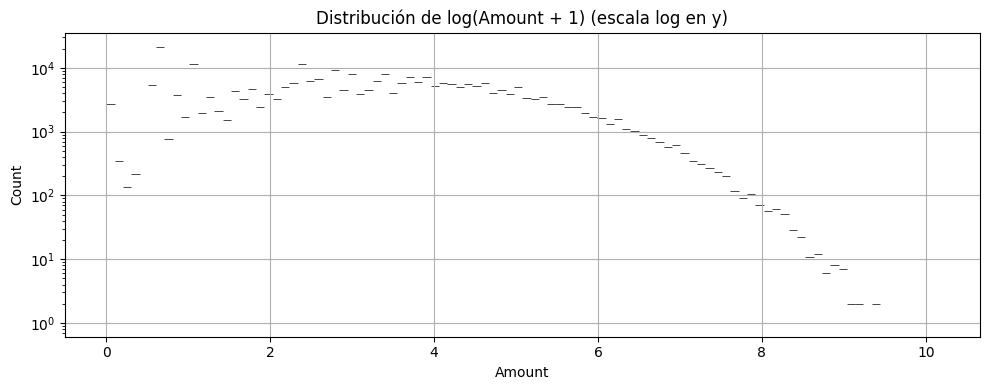

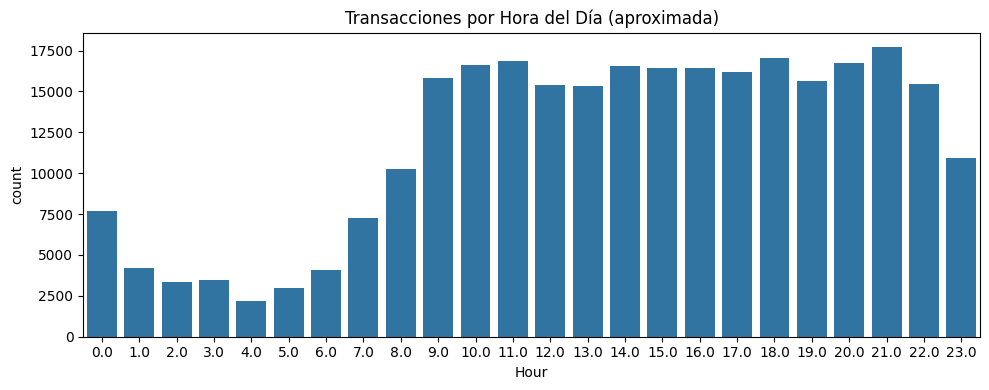

In [26]:
print('Amount descr:', df['Amount'].describe())
print('Time descr:', df['Time'].describe())

#Histograma Amount (raw)
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'], bins=100, log_scale=(False, True)) # log y-axis para ver cola
plt.title('Distribución de Amount (escala log en y)')
plt.grid(True)
plt.tight_layout()
plt.show()

#Histograma Amount (log transform)
plt.figure(figsize=(10,4))
sns.histplot(np.log1p(df['Amount']), bins=100, log_scale=(False, True)) # log1p para evitar log(0)
plt.title('Distribución de log(Amount + 1) (escala log en y)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Time: distribución por hora aproximada
df['Hour'] = (df['Time'] // 3600) % 24
plt.figure(figsize=(10,4))
sns.countplot(x='Hour', data=df)
plt.title('Transacciones por Hora del Día (aproximada)')
plt.tight_layout()
plt.show()



🔎✨ **Correlación con la clase y selección de features más distintivas (univariado)**

En esta sección se identifican las variables que presentan mayor diferencia entre transacciones fraudulentas y no fraudulentas, utilizando la correlación absoluta y la comparación de medias. Este análisis permite destacar las features más relevantes para la detección de fraude y orientar el enfoque del modelado. 📈🚩

In [28]:
#Correlación absoluta con la clase
corrs = df.corr()['Class'].abs().sort_values(ascending=False)
print('Correlaciones absolutas con la clase:\n', corrs)

#Media por clase y diferencia absoluta
means = df.groupby('Class').mean().T
means['Diff_abs'] = (means[1] - means[0]).abs()
top_diff = means.sort_values('Diff_abs', ascending=False).head(15)
display(top_diff[['Diff_abs', 0, 1]])

Correlaciones absolutas con la clase:
 Class     1.000000
V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Hour      0.017109
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64


Class,Diff_abs,0,1
Time,14091.395347,94838.202258,80746.806911
Amount,33.920299,88.291022,122.211321
V3,7.045452,0.012171,-7.033281
V14,6.983787,0.012064,-6.971723
V17,6.677371,0.011535,-6.665836
V12,6.270225,0.010832,-6.259393
V10,5.686707,0.009824,-5.676883
V7,5.578368,0.009637,-5.568731
V1,4.780206,0.008258,-4.771948
V4,4.549889,-0.007860,4.542029


🚦🔬 **Correlación con la clase y selección de features más distintivas (análisis univariado)**

En esta sección se identifican las variables que presentan mayor diferencia entre transacciones fraudulentas y no fraudulentas, utilizando la correlación absoluta y la comparación de medias. Este análisis permite destacar las features más relevantes para la detección de fraude y orientar el enfoque del modelado. 📈🚩

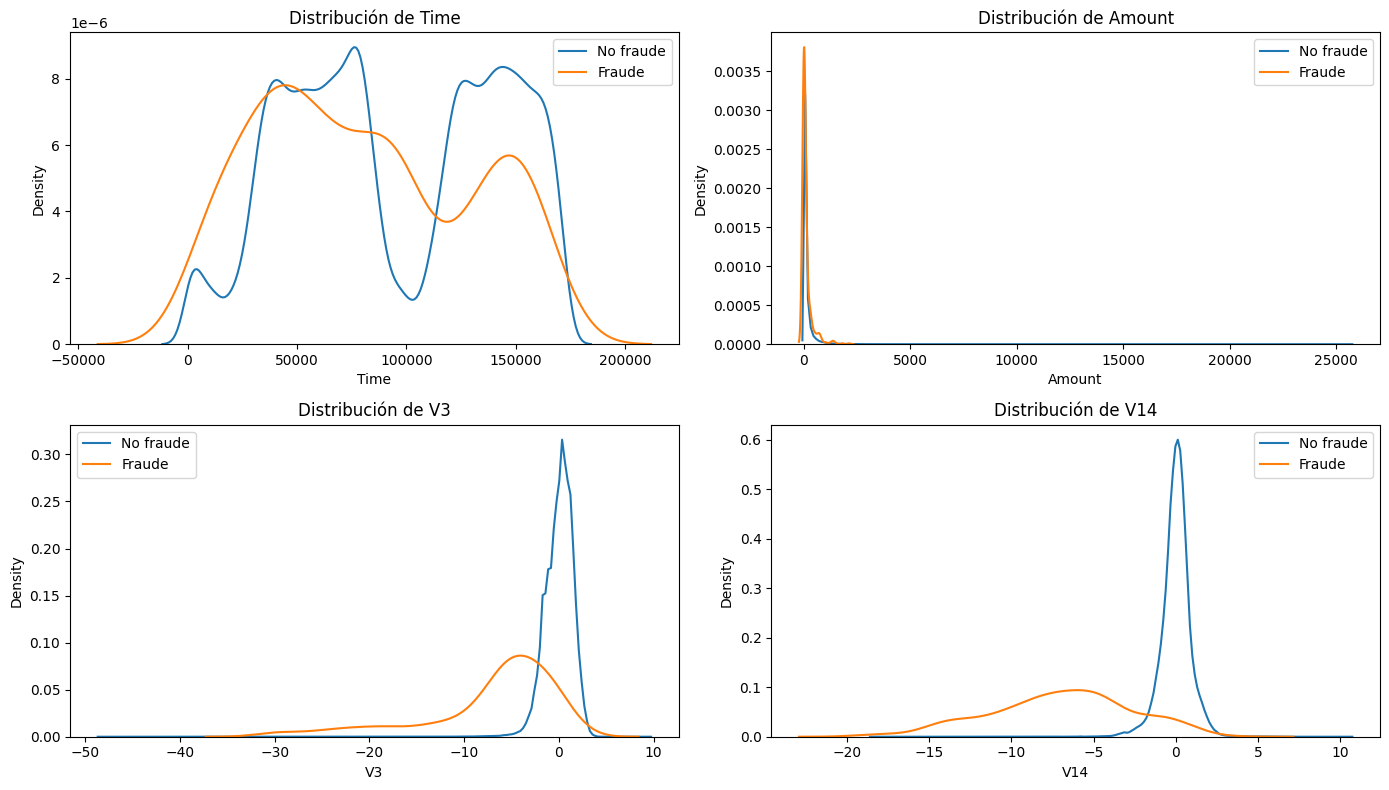

In [30]:
# Elegir las top 4 features según diff_abs (ajusta si quieres otras)
top_feats = top_diff.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, feat in enumerate(top_feats):
    ax = axes[idx // 2, idx % 2]
    sns.kdeplot(df.loc[df['Class']==0, feat], label='No fraude', bw_adjust=1, ax=ax)
    sns.kdeplot(df.loc[df['Class']==1, feat], label='Fraude', bw_adjust=1, ax=ax)
    ax.set_title(f"Distribución de {feat}")
    ax.legend()
plt.tight_layout()
plt.show()


🚩🔍 **Correlación con la clase y selección de las features más distintivas (análisis univariado)**

Se identifican las variables que presentan mayor diferencia entre transacciones fraudulentas y no fraudulentas, utilizando la correlación absoluta y la comparación de medias.  
Las features con mayor poder discriminativo (por diferencia absoluta de medias) son: **Time**, **Amount**, **V3** y **V14**.  
Este análisis permite destacar las variables más relevantes para la detección de fraude y orientar el enfoque del modelado. 📈✨


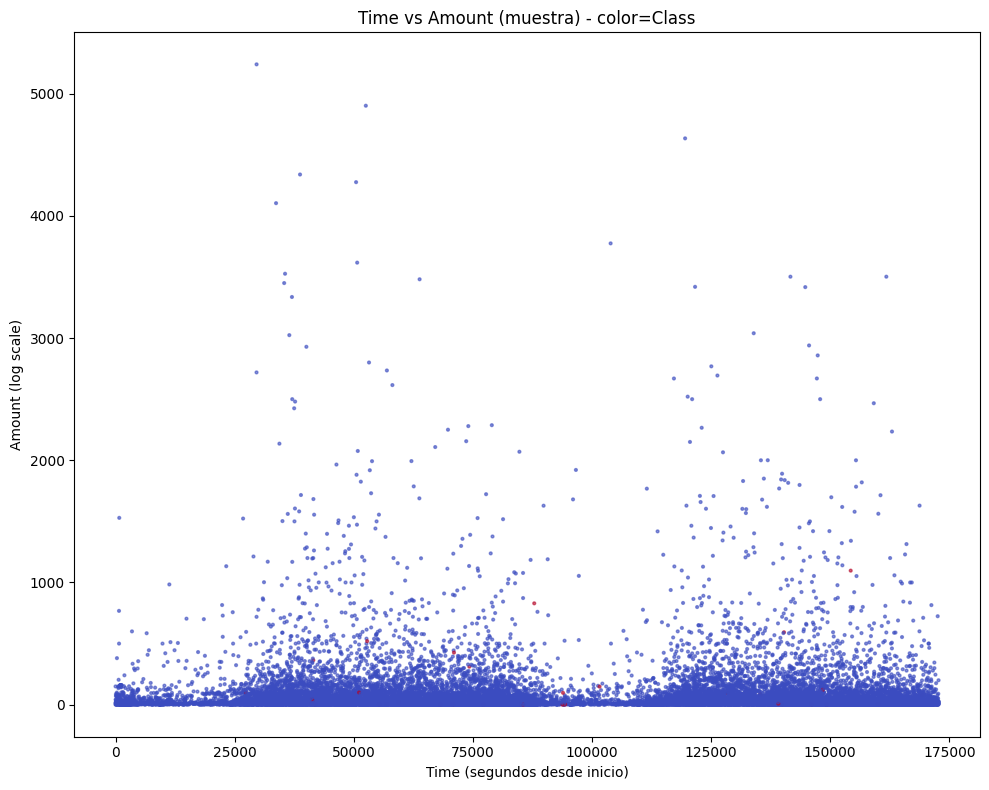

In [31]:
# Muestreo para plotear rápido
sample = df.sample(n=20000, random_state=42)  # Muestra aleatoria para visualización
plt.figure(figsize=(10,8))
plt.scatter(sample['Time'], sample['Amount'], s=4, c=sample['Class'], cmap='coolwarm', alpha=0.6)
plt.title('Time vs Amount (muestra) - color=Class')
plt.xlabel('Time (segundos desde inicio)')
plt.ylabel('Amount (log scale)')
plt.tight_layout()
plt.show()

📅📈 **Recuento temporal de fraudes**

En esta sección se analiza cómo varía la tasa de fraude a lo largo del tiempo, agrupando las transacciones por día. Se visualiza la evolución diaria del porcentaje de fraudes detectados, lo que permite identificar posibles patrones, tendencias o anomalías temporales en el comportamiento fraudulento. 🔍🚩

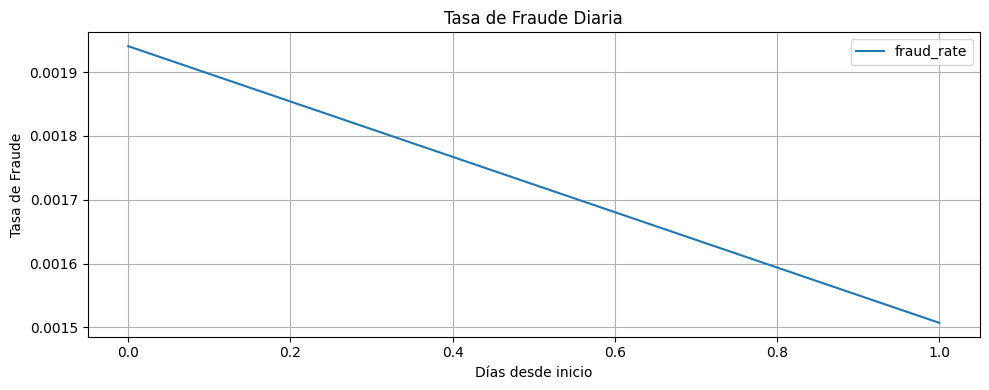

In [32]:
# Agrupar por ventana temporal
df['day'] = (df['Time'] // 86400).astype(int) # días desde inicio
agg = df.groupby('day')['Class'].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'fraudes'})
agg['fraud_rate'] = agg['fraudes'] / agg['total']
agg.plot(y='fraud_rate', figsize=(10,4), title='Tasa de Fraude Diaria')
plt.ylabel('Tasa de Fraude')
plt.xlabel('Días desde inicio')
plt.grid(True)
plt.tight_layout()
plt.show()

💾📤 **Guardar resultados EDA / exportar muestras**

En esta sección se almacenan los resultados clave del análisis exploratorio y se exportan muestras balanceadas del dataset. Esto facilita pruebas rápidas, reproducibilidad y el uso eficiente de los datos en etapas posteriores del proyecto.  
¡Asegúrate de guardar tus avances y trabajar siempre con datos preparados! 🚀🗂️

In [33]:
#Guardar un CSV con un muestreo balanceado para pruebas rápidas
fraud = df[df['Class'] == 1].sample(frac=1, random_state=42).copy()
nonfraud = df[df['Class'] == 0].sample(n=fraud.shape[0]*5, random_state=42)  # 5x no fraude
balanced_sample = pd.concat([fraud, nonfraud]).sample(frac=1, random_state=42)  # mezclar

output_path = '../data/processed/eda_balanced_sample.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
balanced_sample.to_csv(output_path, index=False)
print(f'Guardado sample balanceado en {output_path}')

Guardado sample balanceado en ../data/processed/eda_balanced_sample.csv
